# Атрибуты и эталон

Справочники атрибутов по классам и эталонные выгрузки: что в них лежит, какие типы, как связаны единицы, какая доля значений вообще заполнена.


## Подготовка

Те же пакеты, что в `eda_docs.ipynb`. Долю заполненных значений удобнее считать по нормализованному `ground_truth.jsonl` (если он рядом в research-репо), чем вручную склеивать все листы Excel.


In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import xlrd

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
plt.rcParams.update(
    {
        "figure.figsize": (7, 3.5),
        "axes.grid": True,
        "axes.axisbelow": True,
        "font.size": 11,
        "font.family": "DejaVu Sans",
    }
)

CLASS_LABEL = {
    "bak": "Баки",
    "heat_exchanger": "Теплообменники",
    "strainer": "Фильтры сетчатые",
}
CLASS_ORDER = ["bak", "heat_exchanger", "strainer"]


def resolve_data_root() -> Path:
    env = os.environ.get("NSI_DATA_ROOT")
    candidates: list[Path] = []
    if env:
        candidates.append(Path(env).expanduser())
    candidates.append(Path.home() / "projects/nsi-attribute-extraction/data.local")
    cwd = Path.cwd()
    candidates.extend(
        [
            cwd / "data.local",
            cwd.parent / "nsi-attribute-extraction" / "data.local",
        ]
    )
    for c in candidates:
        if (c / "input_data_ukidim").is_dir():
            return c.resolve()
    raise FileNotFoundError("Не найден data.local/input_data_ukidim. Укажите NSI_DATA_ROOT.")


def resolve_processed_ukidim(data_root: Path) -> Path | None:
    candidates = [
        data_root.parent / "research" / "datasets" / "processed" / "ukidim",
        Path.home() / "projects/nsi-attribute-extraction/research/datasets/processed/ukidim",
        Path.cwd().parent / "nsi-attribute-extraction/research/datasets/processed/ukidim",
    ]
    for c in candidates:
        if (c / "ground_truth.jsonl").is_file():
            return c.resolve()
    return None


DATA = resolve_data_root()
UKI = DATA / "input_data_ukidim"
HAND = DATA / "input_data_handmade"
PROCESSED = resolve_processed_ukidim(DATA)

print("DATA =", DATA)
print("PROCESSED =", PROCESSED)


DATA = /home/fyodebadylo/projects/nsi-attribute-extraction/data.local
PROCESSED = /home/fyodebadylo/projects/nsi-attribute-extraction/research/datasets/processed/ukidim


## Что внутри справочника атрибутов

На класс — `attributes_set.xlsx`: код, имя, альтернативные названия, тип, enum, единица.


In [2]:
def load_attrs(class_code: str) -> pd.DataFrame:
    df = pd.read_excel(UKI / "meta" / class_code / "attributes_set.xlsx")
    # колонка флага чуть по-разному названа в разных классах
    if "for_extract" in df.columns and "for_extraction" not in df.columns:
        df = df.rename(columns={"for_extract": "for_extraction"})
    return df


attr_tables = {code: load_attrs(code) for code in CLASS_ORDER}
catalog = pd.DataFrame(
    [
        {
            "класс": CLASS_LABEL[code],
            "атрибутов": len(df),
            "number": int((df["type"] == "number").sum()),
            "string": int((df["type"] == "string").sum()),
            "enum": int((df["type"] == "enum").sum()),
            "bool": int((df["type"] == "bool").sum()),
            "с code_unit": int(df["code_unit"].notna().sum()),
            "с enum_list": int(df["enum_list"].notna().sum()),
        }
        for code, df in attr_tables.items()
    ]
)
catalog


,класс,атрибутов,number,string,enum,bool,с code_unit,с enum_list
0,Баки,170,88,25,47,10,83,57
1,Теплообменники,183,118,28,35,2,107,37
2,Фильтры сетчатые,147,84,24,37,2,75,39


In [3]:
type_mix = (
    pd.concat(
        [
            df.assign(класс=CLASS_LABEL[code])[["класс", "type"]]
            for code, df in attr_tables.items()
        ],
        ignore_index=True,
    )
    .value_counts(["класс", "type"])
    .unstack(fill_value=0)
    .reindex(columns=["number", "string", "enum", "bool"])
)
type_mix


type,number,string,enum,bool
класс,,,,
Баки,88,25,47,10
Теплообменники,118,28,35,2
Фильтры сетчатые,84,24,37,2


eda_attrs.ipynb:6:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


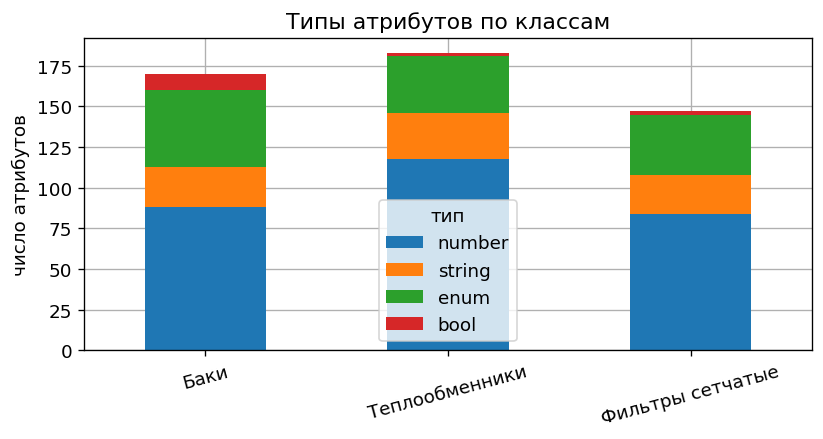

In [4]:
ax = type_mix.plot(kind="bar", stacked=True, figsize=(7, 3.8))
ax.set_ylabel("число атрибутов")
ax.set_xlabel("")
ax.set_title("Типы атрибутов по классам")
ax.legend(title="тип")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Вывод.** Для каждого класса задан фиксированный список характеристик. Задача выглядит не как «найти что угодно в PDF», а как заполнение конкретных слотов.


## Типы и синонимы

В справочнике размечены `number` / `string` / `enum` / `bool` и альтернативные имена. Смотрим, насколько типы разнообразны и как часто у одного атрибута несколько названий — в ТЗ формулировки часто не совпадают с MDM дословно.


In [5]:
alt_stats = []
for code, df in attr_tables.items():
    counts = (
        df["alt_names"]
        .fillna("")
        .astype(str)
        .map(lambda s: len([x for x in s.replace("|", "\n").split("\n") if x.strip()]) if s.strip() else 0)
    )
    alt_stats.append(
        {
            "класс": CLASS_LABEL[code],
            "медиана числа имён": float(counts.median()),
            "макс. имён у атрибута": int(counts.max()),
            "атрибутов без alt_names": int((counts == 0).sum()),
        }
    )
pd.DataFrame(alt_stats)


,класс,медиана числа имён,макс. имён у атрибута,атрибутов без alt_names
0,Баки,2.0,11,0
1,Теплообменники,2.0,11,0
2,Фильтры сетчатые,2.0,14,0


**Вывод.** Синонимы встречаются систематически: одно и то же в документе может называться иначе, чем в справочнике. Тип тоже важен — от него зависит, что считать совпадением с эталоном (число, элемент списка, да/нет).


## Числа и единицы

У части `number` есть `code_unit`, у части нет (вероятности, счётные величины и т.п.). В Excel-эталоне значение и единица обычно соседние колонки.


In [6]:
unit_rows = []
for code, df in attr_tables.items():
    num = df[df["type"] == "number"]
    unit_rows.append(
        {
            "класс": CLASS_LABEL[code],
            "number всего": len(num),
            "с code_unit": int(num["code_unit"].notna().sum()),
            "без code_unit": int(num["code_unit"].isna().sum()),
        }
    )
units = pd.DataFrame(unit_rows)
units


,класс,number всего,с code_unit,без code_unit
0,Баки,88,83,5
1,Теплообменники,118,107,11
2,Фильтры сетчатые,84,75,9


In [7]:
# как выглядят колонки эталона: имя атрибута + соседняя «ед.из.»
def unit_column_share(class_code: str) -> dict:
    book = xlrd.open_workbook(str(UKI / "meta" / class_code / "ground_truth.xls"))
    skip = {"EnoviaOID", "Classification", "Person", "RelDoc", "HbcCompanyList", "HbcListInfo"}
    attr_headers = 0
    unit_headers = 0
    for sheet in book.sheets():
        if sheet.name in skip:
            continue
        for c in range(sheet.ncols):
            h = str(sheet.cell_value(0, c)).replace("\n", " ").strip().lower()
            if not h:
                continue
            if "ед.из" in h:
                unit_headers += 1
            else:
                attr_headers += 1
    return {
        "класс": CLASS_LABEL[class_code],
        "листов с атрибутами": sum(
            1 for s in book.sheets() if s.name not in skip
        ),
        "заголовков значений (оценка)": attr_headers,
        "заголовков единиц": unit_headers,
    }


pd.DataFrame([unit_column_share(c) for c in CLASS_ORDER])


,класс,листов с атрибутами,заголовков значений (оценка),заголовков единиц
0,Баки,2,182,84
1,Теплообменники,4,375,179
2,Фильтры сетчатые,4,243,97


**Вывод.** Для многих числовых характеристик единица — часть ответа. Сверять только «голое» число с эталоном будет недостаточно.


## Насколько эталон заполнен

Пары «позиция × атрибут» по эталонной выгрузке: какая доля слотов имеет значение.


In [8]:
if PROCESSED is None:
    raise FileNotFoundError(
        "Не найден research/datasets/processed/ukidim/ground_truth.jsonl рядом с data.local"
    )

gt_rows = [
    json.loads(line)
    for line in (PROCESSED / "ground_truth.jsonl").read_text(encoding="utf-8").splitlines()
    if line.strip()
]
manifest = pd.read_excel(HAND / "ukidim_pdf_files_manifest.xlsx")
eos_to_class = {
    int(r["Идентификатор ЕОС НСИ"]): r["Код класса"]
    for _, r in manifest.iterrows()
}

sparse = []
for code in CLASS_ORDER:
    subset = [r for r in gt_rows if eos_to_class.get(r["gid"]) == code]
    total = len(subset)
    filled = sum(1 for r in subset if r.get("value") is not None)
    gids = {r["gid"] for r in subset}
    sparse.append(
        {
            "класс": CLASS_LABEL[code],
            "позиции": len(gids),
            "пар позиция–атрибут": total,
            "с значением": filled,
            "доля заполненных": round(filled / total, 3) if total else None,
        }
    )
sparsity = pd.DataFrame(sparse)
sparsity


,класс,позиции,пар позиция–атрибут,с значением,доля заполненных
0,Баки,10,1620,743,0.459
1,Теплообменники,8,1400,598,0.427
2,Фильтры сетчатые,10,1390,607,0.437


eda_attrs.ipynb:17:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


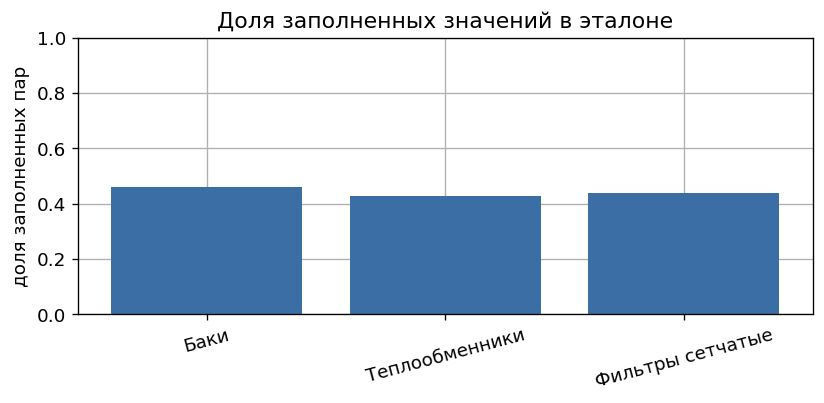

In [9]:
fig, ax = plt.subplots()
ax.bar(sparsity["класс"], sparsity["доля заполненных"], color="#3b6ea5")
ax.set_ylim(0, 1)
ax.set_ylabel("доля заполненных пар")
ax.set_title("Доля заполненных значений в эталоне")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Вывод.** Пустых слотов больше половины. «Нет значения» — обычное состояние, не редкий брак выгрузки. Оценка только по найденным числам будет врать: нужно различать корректную пустоту, ошибку и пропуск.


## Как устроен сырой эталон

Выгрузка RECPart на нескольких листах, рядом со значением колонка единицы, плюс служебные вкладки. Оцениваем, насколько это удобно брать as-is.


In [10]:
gt_shape = []
for code in CLASS_ORDER:
    book = xlrd.open_workbook(str(UKI / "meta" / code / "ground_truth.xls"))
    skip = {"EnoviaOID", "Classification", "Person", "RelDoc", "HbcCompanyList", "HbcListInfo"}
    attr_sheets = [s.name for s in book.sheets() if s.name not in skip]
    gt_shape.append(
        {
            "класс": CLASS_LABEL[code],
            "листов всего": book.nsheets,
            "листов с характеристиками": len(attr_sheets),
            "строк в GT jsonl": int(sparsity.loc[sparsity["класс"] == CLASS_LABEL[code], "пар позиция–атрибут"].iloc[0]),
        }
    )
pd.DataFrame(gt_shape)


,класс,листов всего,листов с характеристиками,строк в GT jsonl
0,Баки,8,2,1620
1,Теплообменники,10,4,1400
2,Фильтры сетчатые,10,4,1390


**Вывод.** Сырой Excel плохо подходит как непосредственный ground truth: легко дважды учесть один атрибут с разных листов или принять колонку единицы за отдельное значение. Перед экспериментами лучше свести к парам по справочнику класса.


## Коротко по атрибутам и эталону

Слоты задаёт справочник; тип и единица влияют на то, что считать правильным ответом; пустые значения — норма; сырую выгрузку лучше нормализовать. Это видно уже на этапе разбора данных.
